Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Kullanılan dosya yolu: /content/drive/MyDrive/veri.xlsx

İlk 5 satır:
            Zaman damgası  B1  D1  D2  D3  D4  D5  D6  D7  D8  ...  G10  G11  \
0 2025-12-16 12:13:58.356   1   1   3  15   1   3   2   2   1  ...    5    5   
1 2025-12-16 12:14:11.881   1   2   2   5   1   3   2   1   2  ...    4    4   
2 2025-12-16 12:14:22.348   1   1   2  10   2   4   3   1   2  ...    5    4   
3 2025-12-16 12:15:12.838   1   1   2   4   2   3   4   1   2  ...    1    1   
4 2025-12-16 12:15:29.518   1   2   1  10   2   4   4   2   1  ...    3    3   

   G12  G13  G14  G15  G16  G17  G18  G19  
0    3    4    3    1    3    4    3    4  
1    2    2    3    5    1    1    5    1  
2    4    4    4    3    4    5    4    4  
3    1    1    1    1    1    1    1    1  
4    3    3    2    3    3    3    3    3  

[5 rows x 42 columns]

Sütun adları:
['Zaman damgası', 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/factor_analyzer/factor_analyzer.py:663: UserWarning: No rotation will be performed when the number of factors equals 1.
  warnings.warn(
/tmp/ipykernel_15835/2200952822.py:193: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(corr_df[col], corr_df["kaygi_ort"])


              precision    recall  f1-score   support

           0       0.50      0.48      0.49        27
           1       0.33      0.35      0.34        20

    accuracy                           0.43        47
   macro avg       0.42      0.42      0.42        47
weighted avg       0.43      0.43      0.43        47


Random Forest
Accuracy : 0.4894
Precision: 0.375
Recall   : 0.3
F1 Score : 0.3333

Confusion Matrix:
[[17 10]
 [14  6]]

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.63      0.59        27
           1       0.38      0.30      0.33        20

    accuracy                           0.49        47
   macro avg       0.46      0.46      0.46        47
weighted avg       0.47      0.49      0.48        47


Karar Ağacı
Accuracy : 0.5532
Precision: 0.4286
Recall   : 0.15
F1 Score : 0.2222

Confusion Matrix:
[[23  4]
 [17  3]]

Classification Report:
              precision    recall  f1-score   support

 

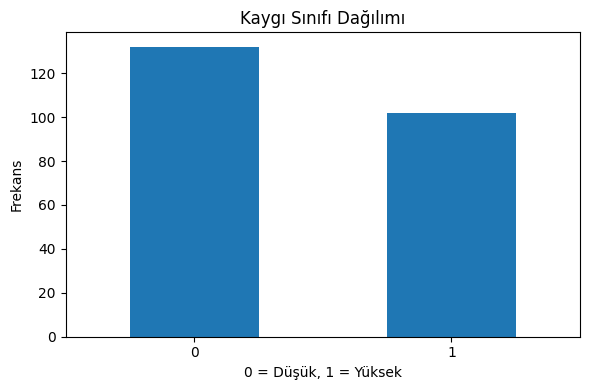

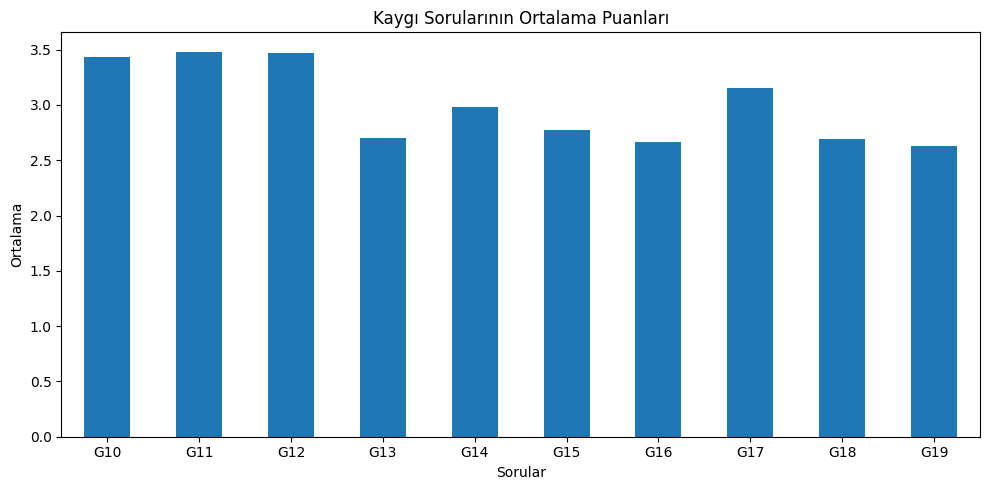

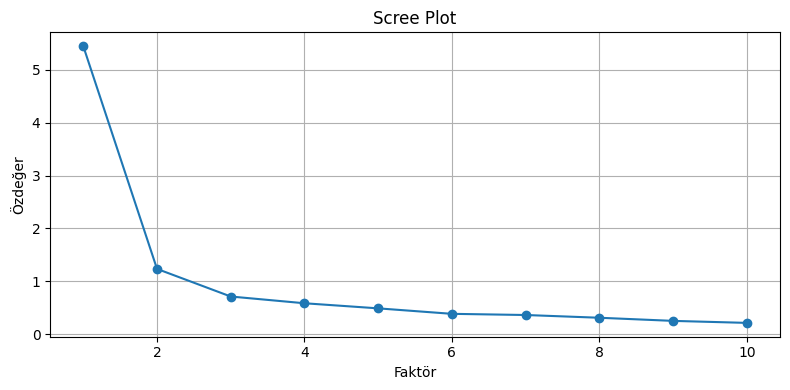

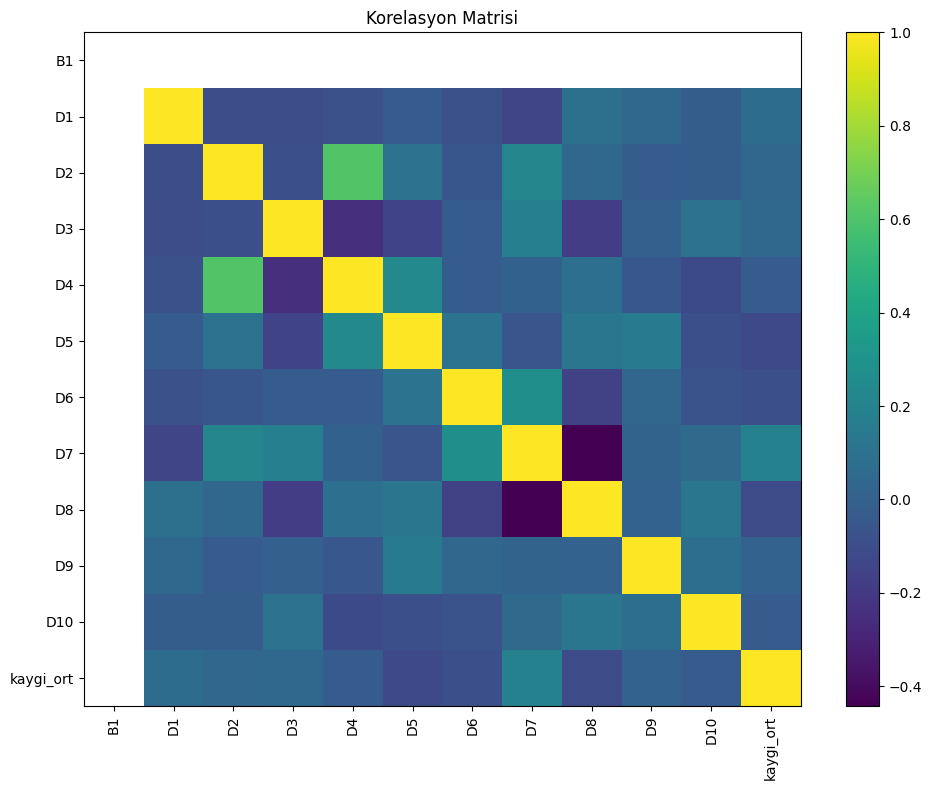

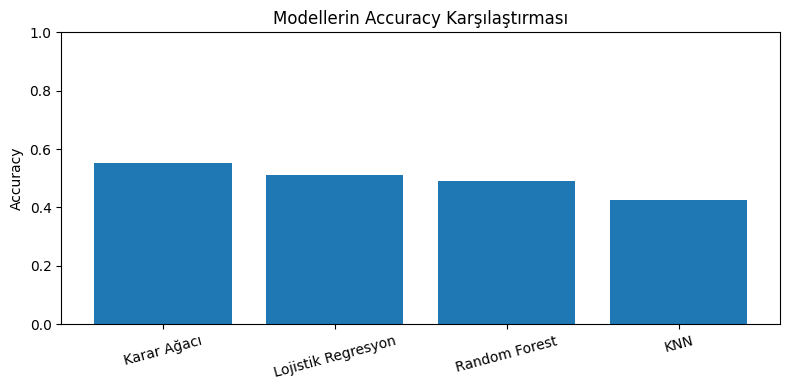

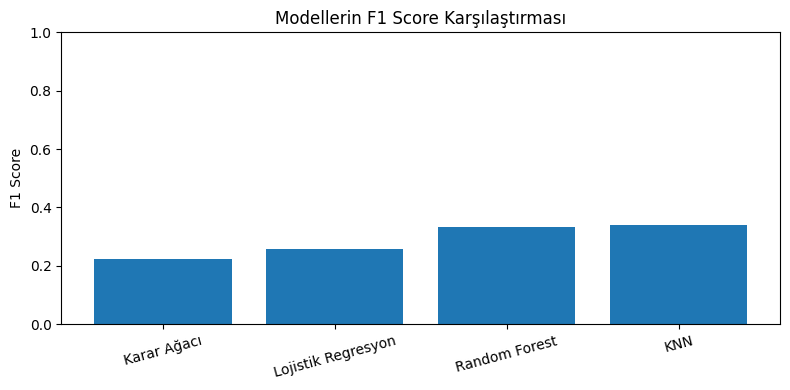


Excel çıktısı kaydedildi:
/content/drive/MyDrive/proje_analiz_sonuclari.xlsx

========== KISA ÖZET ==========
Cronbach Alpha: 0.9053
KMO: 0.9033
Bartlett p-değeri: 1.21277173053555e-244
En başarılı model: Karar Ağacı
En yüksek Accuracy: 0.5532
R-kare: 0.0789


In [5]:
# =========================================================
# VERİ ANALİZİ PROJESİ
# =========================================================

# =========================================================
# 1) DRIVE BAĞLAMA
# =========================================================
from google.colab import drive
drive.mount('/content/drive')

# =========================================================
# 2) KÜTÜPHANELER
# =========================================================
!pip install factor_analyzer -q

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression

import statsmodels.api as sm

# =========================================================
# 3) DOSYA BULMA
# =========================================================
drive_path = "/content/drive/MyDrive/veri.xlsx"
colab_path = "/content/veri.xlsx"

if os.path.exists(drive_path):
    dosya_yolu = drive_path
elif os.path.exists(colab_path):
    dosya_yolu = colab_path
else:
    raise FileNotFoundError("veri.xlsx bulunamadı. Dosyayı Drive'a veya Colab'a yükleyin.")

print("Kullanılan dosya yolu:", dosya_yolu)

# =========================================================
# 4) VERİYİ OKUMA
# =========================================================
df = pd.read_excel(dosya_yolu)
df.columns = df.columns.str.strip()

print("\nİlk 5 satır:")
print(df.head())

print("\nSütun adları:")
print(df.columns.tolist())

# =========================================================
# 5) GEREKLİ SÜTUNLAR
# =========================================================
kaygi_sorulari = ['G10','G11','G12','G13','G14','G15','G16','G17','G18','G19']
bagimsiz_deg = ['B1','D1','D2','D3','D4','D5','D6','D7','D8','D9','D10']

gerekli_sutunlar = kaygi_sorulari + bagimsiz_deg
eksik = [col for col in gerekli_sutunlar if col not in df.columns]

if len(eksik) > 0:
    raise ValueError(f"Eksik sütunlar var: {eksik}")

# =========================================================
# 6) KAYGI SORULARINI SAYISALA ÇEVİRME
# =========================================================
for col in kaygi_sorulari:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=kaygi_sorulari).copy()

# =========================================================
# 7) TANIMLAYICI İSTATİSTİKLER
# =========================================================
desc = df[kaygi_sorulari].describe().T
desc["varyans"] = df[kaygi_sorulari].var()
print("\nTANIMLAYICI İSTATİSTİKLER")
print(desc)

# =========================================================
# 8) CRONBACH ALPHA
# =========================================================
def cronbach_alpha(data):
    items = data.to_numpy()
    item_var = items.var(axis=0, ddof=1)
    total_var = items.sum(axis=1).var(ddof=1)
    n_items = data.shape[1]
    alpha = (n_items / (n_items - 1)) * (1 - (item_var.sum() / total_var))
    return alpha

alpha = cronbach_alpha(df[kaygi_sorulari])
print("\nCronbach Alpha:", round(alpha, 4))

# =========================================================
# 9) KMO VE BARTLETT
# =========================================================
kmo_all, kmo_model = calculate_kmo(df[kaygi_sorulari])
chi_square, p_value = calculate_bartlett_sphericity(df[kaygi_sorulari])

print("KMO:", round(kmo_model, 4))
print("Bartlett Ki-Kare:", round(chi_square, 4))
print("Bartlett p-değeri:", p_value)

# =========================================================
# 10) FAKTÖR ANALİZİ
# =========================================================
fa_check = FactorAnalyzer(rotation=None)
fa_check.fit(df[kaygi_sorulari])

eigen_values, vectors = fa_check.get_eigenvalues()

print("\nÖzdeğerler:")
for i, val in enumerate(eigen_values, start=1):
    print(f"Faktör {i}: {round(val, 4)}")

# Tek faktörlü çözüm
fa = FactorAnalyzer(n_factors=1, rotation="varimax")
fa.fit(df[kaygi_sorulari])

loadings = pd.DataFrame(
    fa.loadings_,
    index=kaygi_sorulari,
    columns=["Faktör Yükü"]
)

print("\nFaktör Yükleri:")
print(loadings)

# =========================================================
# 11) KAYGI ORTALAMASI VE SINIFI
# =========================================================
df["kaygi_ort"] = df[kaygi_sorulari].mean(axis=1)

medyan = df["kaygi_ort"].median()
df["kaygi_sinif"] = np.where(df["kaygi_ort"] > medyan, 1, 0)

print("\nKaygı sınıf dağılımı:")
print(df["kaygi_sinif"].value_counts())

# =========================================================
# 12) BAĞIMSIZ DEĞİŞKENLERİ HAZIRLAMA
# =========================================================
X = df[bagimsiz_deg].copy()
y_class = df["kaygi_sinif"].copy()
y_reg = df["kaygi_ort"].copy()

label_maps = {}

for col in X.columns:
    if X[col].dtype == "object":
        le = LabelEncoder()
        X[col] = X[col].astype(str).fillna("Eksik")
        X[col] = le.fit_transform(X[col])
        label_maps[col] = dict(zip(le.classes_, le.transform(le.classes_)))

X = X.fillna(0)

print("\nKodlanan kategorik değişkenler:")
if label_maps:
    for col, mapping in label_maps.items():
        print(col, ":", mapping)
else:
    print("Kategorik değişken kodlanmadı.")

# =========================================================
# 13) KORELASYON ANALİZİ
# =========================================================
korelasyon_deg = bagimsiz_deg + ["kaygi_ort"]
corr_df = X.copy()
corr_df["kaygi_ort"] = df["kaygi_ort"].values

corr_matrix = corr_df.corr(numeric_only=True)

print("\nKORELASYON MATRİSİ")
print(corr_matrix)

# kaygi_ort ile korelasyon tablosu
kaygi_corr_list = []
for col in bagimsiz_deg:
    r, p = pearsonr(corr_df[col], corr_df["kaygi_ort"])
    kaygi_corr_list.append([col, r, p])

kaygi_corr_table = pd.DataFrame(
    kaygi_corr_list,
    columns=["Değişken", "Pearson r", "p-değeri"]
).sort_values(by="Pearson r", ascending=False)

print("\nKaygı Ortalaması ile Korelasyon")
print(kaygi_corr_table)

# =========================================================
# 14) DOĞRUSAL REGRESYON (kaygi_ort)
# =========================================================
X_reg = sm.add_constant(X)
ols_model = sm.OLS(y_reg, X_reg).fit()

regression_table = pd.DataFrame({
    "Değişken": ols_model.params.index,
    "Katsayı": ols_model.params.values,
    "p-değeri": ols_model.pvalues.values
})

print("\nDOĞRUSAL REGRESYON SONUÇLARI")
print(regression_table)
print("\nR-kare:", round(ols_model.rsquared, 4))
print("Adj. R-kare:", round(ols_model.rsquared_adj, 4))

# =========================================================
# 15) SINIFLANDIRMA İÇİN EĞİTİM / TEST AYIRMA
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================================================
# 16) MODEL DEĞERLENDİRME FONKSİYONU
# =========================================================
sonuclar = []
conf_matrices = {}

def model_degerlendir(model_adi, model, Xtr, Xts):
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xts)

    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1  = f1_score(y_test, y_pred, zero_division=0)

    cm = confusion_matrix(y_test, y_pred)
    conf_matrices[model_adi] = cm

    print("\n===================================")
    print(model_adi)
    print("===================================")
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(pre, 4))
    print("Recall   :", round(rec, 4))
    print("F1 Score :", round(f1, 4))
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    sonuclar.append([model_adi, acc, pre, rec, f1])

# =========================================================
# 17) MAKİNE ÖĞRENMESİ MODELLERİ
# =========================================================
knn = KNeighborsClassifier(n_neighbors=5)
model_degerlendir("KNN", knn, X_train_scaled, X_test_scaled)

rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
model_degerlendir("Random Forest", rf, X_train, X_test)

dt = DecisionTreeClassifier(max_depth=4, random_state=42)
model_degerlendir("Karar Ağacı", dt, X_train, X_test)

lr = LogisticRegression(max_iter=1000)
model_degerlendir("Lojistik Regresyon", lr, X_train_scaled, X_test_scaled)

# =========================================================
# 18) MODEL SONUÇ TABLOSU
# =========================================================
sonuc_df = pd.DataFrame(
    sonuclar,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
).sort_values(by="Accuracy", ascending=False)

print("\nMODEL KARŞILAŞTIRMA TABLOSU")
print(sonuc_df)

en_iyi_model = sonuc_df.iloc[0]
print("\nEn başarılı model:", en_iyi_model["Model"])
print("Accuracy:", round(en_iyi_model["Accuracy"], 4))

# =========================================================
# 19) GRAFİKLER
# =========================================================

# Grafik 1: Kaygı sınıf dağılımı
plt.figure(figsize=(6,4))
df["kaygi_sinif"].value_counts().sort_index().plot(kind="bar")
plt.title("Kaygı Sınıfı Dağılımı")
plt.xlabel("0 = Düşük, 1 = Yüksek")
plt.ylabel("Frekans")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Grafik 2: Kaygı soru ortalamaları
plt.figure(figsize=(10,5))
df[kaygi_sorulari].mean().plot(kind="bar")
plt.title("Kaygı Sorularının Ortalama Puanları")
plt.xlabel("Sorular")
plt.ylabel("Ortalama")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Grafik 3: Scree Plot
plt.figure(figsize=(8,4))
plt.plot(range(1, len(eigen_values)+1), eigen_values, marker="o")
plt.title("Scree Plot")
plt.xlabel("Faktör")
plt.ylabel("Özdeğer")
plt.grid(True)
plt.tight_layout()
plt.show()

# Grafik 4: Korelasyon matrisi
plt.figure(figsize=(10,8))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Korelasyon Matrisi")
plt.tight_layout()
plt.show()

# Grafik 5: Accuracy karşılaştırması
plt.figure(figsize=(8,4))
plt.bar(sonuc_df["Model"], sonuc_df["Accuracy"])
plt.title("Modellerin Accuracy Karşılaştırması")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Grafik 6: F1 Score karşılaştırması
plt.figure(figsize=(8,4))
plt.bar(sonuc_df["Model"], sonuc_df["F1 Score"])
plt.title("Modellerin F1 Score Karşılaştırması")
plt.ylabel("F1 Score")
plt.ylim(0,1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# =========================================================
# 20) EXCEL ÇIKTILARI
# =========================================================
kayit_yolu = "/content/drive/MyDrive/proje_analiz_sonuclari.xlsx"

with pd.ExcelWriter(kayit_yolu, engine="openpyxl") as writer:
    desc.to_excel(writer, sheet_name="Tanımlayıcı İstatistik")
    loadings.to_excel(writer, sheet_name="Faktör Yükleri")
    corr_matrix.to_excel(writer, sheet_name="Korelasyon Matrisi")
    kaygi_corr_table.to_excel(writer, sheet_name="Kaygı Korelasyon", index=False)
    regression_table.to_excel(writer, sheet_name="Regresyon", index=False)
    sonuc_df.to_excel(writer, sheet_name="ML Sonuçları", index=False)
    df.to_excel(writer, sheet_name="İşlenmiş Veri", index=False)

print("\nExcel çıktısı kaydedildi:")
print(kayit_yolu)

# =========================================================
# 21) KISA ÖZET ÇIKTISI
# =========================================================
print("\n========== KISA ÖZET ==========")
print("Cronbach Alpha:", round(alpha, 4))
print("KMO:", round(kmo_model, 4))
print("Bartlett p-değeri:", p_value)
print("En başarılı model:", en_iyi_model["Model"])
print("En yüksek Accuracy:", round(en_iyi_model["Accuracy"], 4))
print("R-kare:", round(ols_model.rsquared, 4))

# Yeni Bölüm